# Week 5 Day 5 Lab


In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Recall: Eigenvalues

An eigenvector is a vector $v$ such that

$$Av=\lambda v.$$

where
- $A$ is a matrix
- $\lambda$ is a scalar (called the eigenvalue)



Suppose$
A=
\begin{bmatrix}
4 & 1\\
1 & 3
\end{bmatrix}$ Note that $A=A^T$. We call these matrices *symmetric*. We can compute the eigenvalues and eigenvectors as follows:

In [7]:
A = np.array([[4,1],[1,3]])
np.linalg.eig(A)

EigResult(eigenvalues=array([4.61803399, 2.38196601]), eigenvectors=array([[ 0.85065081, -0.52573111],
       [ 0.52573111,  0.85065081]]))

In [3]:
np.linalg.eig(A)[0][1]*np.array([-0.52573111,  0.85065081])

array([-1.25227364,  2.02622132])

### Recall: Quadratic Forms

Consider

$$f(x)=x^TAx$$

This is called a **quadratic form**. If

```python
x = [x₁,x₂]
```
then

```python
A =
[[4,1],
 [1,3]]
```

gives $$f(x)=4x_1^2+2x_1x_2+3x_2^2.$$

Quadratic forms appear throughout optimization. Most importantly, in eigenvalues.

### The Rayleigh Quotient

The quantity

$$
R(A)=\frac{x^TAx}{x^Tx}
$$

is called the **Rayleigh Quotient**.

One of the most important theorems in linear algebra states

$$
\lambda_{\min}(A)\leq R(A)
\leq \lambda_{\max}(A)
$$

And that for symmetric matrices $\min_{x\neq 0}R(A)=\lambda_{\min}$ and $\max_{x\neq 0}R(A)=\lambda_{\max}$ where the $x$'s that acheive these values are the eigenvectors.

Consider drawing these randomly:

In [29]:
values, vectors = np.linalg.eig(A)

largest = np.max(values)

samples = []

for i in range(5000):
    x = np.random.randn(2)
    x = x/np.linalg.norm(x)
    if i == 4000:
        print(x)
    value = x.T @ A @ x

    samples.append(value)

print(max(samples))
print(largest)

[-0.97756544 -0.21063192]
4.618033926144002
4.618033988749895


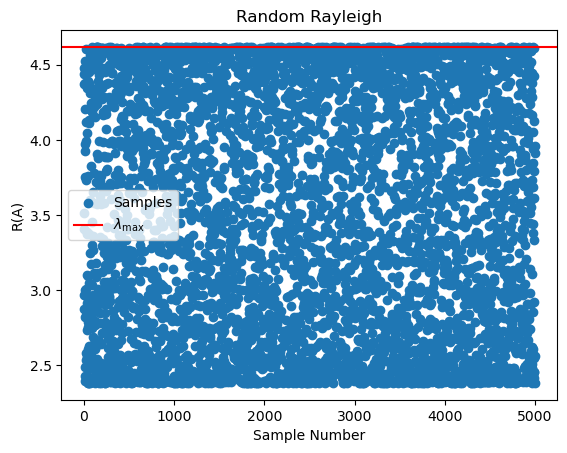

In [6]:
plt.scatter([i for i in range(len(samples))],samples,label='Samples')
plt.axhline(largest, color='red',label=r'$\lambda_{\max}$')
plt.xlabel('Sample Number')
plt.ylabel('R(A)')
plt.title('Random Rayleigh')
plt.legend()

### Problem  1
Write a function that uses `scipy.optimize` to find the largest and smallest eigenvalue of a symmetric two by two matrix.

### Problem 2
Write a function that randomly samples vectors to approximate the largest and smallest eigenvalues. Make this function print the error as well.

In [32]:
from scipy.optimize import minimize

B = np.array([[1, 4], [4, 1]])
def function(matrix):
    values, vectors = np.linalg.eig(matrix)
    print(values)
    return np.min(values), np.max(values)

minimum, maximum = function(B)
maximum
#not sure how to use scipy here, I thought that only worked for functions
a = 1
b = 2
c = 3
d = 4
def f(x1, x2):
    return (x1 * (a*x1 + b*x2) + x2*(c*x1 + d*x2)) / (x1**2 + x2**2)

    

[ 5. -3.]


In [37]:
minimize(f,
         1,1)


TypeError: f() missing 1 required positional argument: 'x2'

In [28]:
def function2(samples):
    samples = np.reshape(samples, (4, 2))
    largest, smallest = np.max(samples[0]), np.min(samples[0])
    for i in samples:
        values, vectors = np.linalg.eig(i)
        if (np.min(values) < smallest):
            smallest = np.min(values)
        if(np.max(values) > largest):
            largest = np.max(values)
    return largest, smallest

C = np.append(B, A)
C = np.reshape(C, (4, 2))
largest, smallest = function2(C)
largest

LinAlgError: 1-dimensional array given. Array must be at least two-dimensional

### Problem 3
Generalize the function from Problem 1 for arbitrary sized matrices.